In [65]:
!pip install mlflow dagshub -q

import numpy as np
import pandas as pd
import os
import mlflow
import mlflow.sklearn
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    return df

In [66]:
import dagshub
dagshub.init(repo_owner='Sula1909', repo_name='ML-Assignment2', mlflow=True)

mlflow.set_tracking_uri("https://dagshub.com/Sula1909/ML-Assignment2.mlflow")

mlflow.set_experiment("XGBoost_Training")

Initialized MLflow to track repo "Sula1909/ML-Assignment2"

Repository Sula1909/ML-Assignment2 initialized!

<Experiment: artifact_location='mlflow-artifacts:/3f39636511fe40c89becc667203bd5f9', creation_time=1777654084520, experiment_id='0', last_update_time=1777654084520, lifecycle_stage='active', name='XGBoost_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [67]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.expand_frame_repr', False)

In [68]:
print("Loading data...")
train_trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_id = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

test_trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_id = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

train = pd.merge(train_trans, train_id, on='TransactionID', how='left')
test = pd.merge(test_trans, test_id, on='TransactionID', how='left')

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

del train_trans, train_id, test_trans, test_id
print(f"Dataset shape: {train.shape}")
print(f"Dataset shape: {test.shape}")

Loading data...
Dataset shape: (590540, 434)
Dataset shape: (506691, 433)


In [69]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [70]:
na_rate = train.isna().mean()
print(na_rate[na_rate > 0.1].sort_values(ascending=False).to_string())

id_24            0.991962
id_25            0.991310
id_07            0.991271
id_08            0.991271
id_21            0.991264
id_26            0.991257
id_22            0.991247
id_23            0.991247
id_27            0.991247
dist2            0.936284
D7               0.934099
id_18            0.923607
D13              0.895093
D14              0.894695
D12              0.890410
id_04            0.887689
id_03            0.887689
D6               0.876068
id_33            0.875895
D9               0.873123
D8               0.873123
id_09            0.873123
id_10            0.873123
id_30            0.868654
id_32            0.868619
id_34            0.868248
id_14            0.864456
V138             0.861237
V141             0.861237
V140             0.861237
V157             0.861237
V149             0.861237
V146             0.861237
V139             0.861237
V142             0.861237
V155             0.861237
V154             0.861237
V153             0.861237
V161        

# EDA & CLEANING

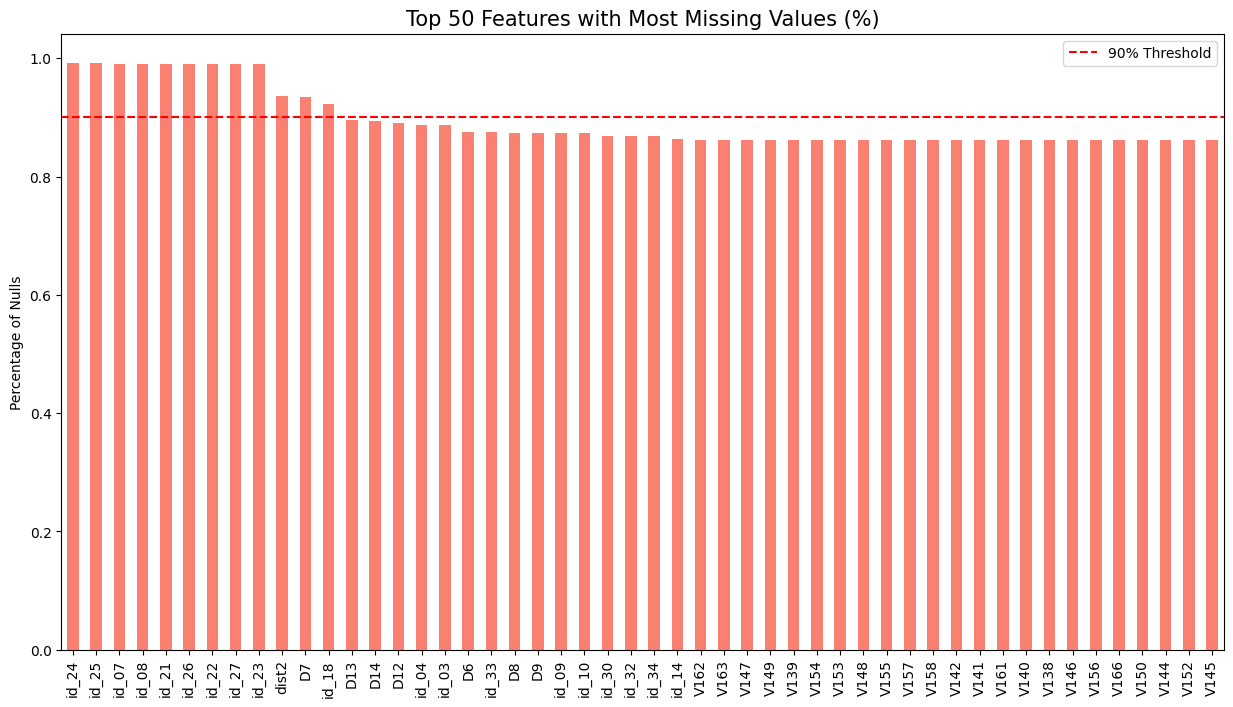

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

null_data = train.isnull().mean().sort_values(ascending=False)[:50]

plt.figure(figsize=(15, 8))
null_data.plot(kind='bar', color='salmon')
plt.title('Top 50 Features with Most Missing Values (%)', fontsize=15)
plt.ylabel('Percentage of Nulls')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.show()

/tmp/ipykernel_57/3930653857.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train['isFraud'], palette='viridis')


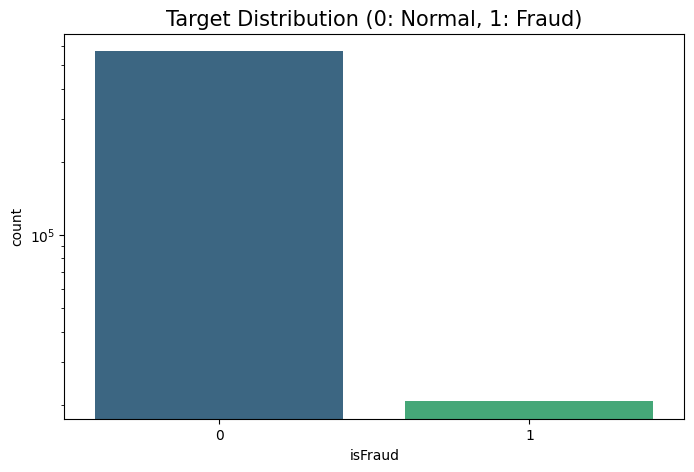

Fraud Percentage: 3.50%


In [72]:
plt.figure(figsize=(8, 5))
sns.countplot(x=train['isFraud'], palette='viridis')
plt.title('Target Distribution (0: Normal, 1: Fraud)', fontsize=15)
plt.yscale('log') # Log Scale
plt.show()

print(f"Fraud Percentage: {train['isFraud'].mean()*100:.2f}%")

In [73]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

***> TransactionDT Analysis***

In [74]:
print(train['TransactionDT'].dtype)

print(train["TransactionDT"].isnull().sum())

print(train["TransactionDT"].nunique())

int32
0
573349


In [75]:
train[['TransactionDT']].describe().astype(int)

,TransactionDT
count,590540
mean,7372311
std,4617223
min,86400
25%,3027057
50%,7306527
75%,11246620
max,15811131


/tmp/ipykernel_57/1803339530.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['TransactionDT'],kde = False,bins=60)
/tmp/ipykernel_57/1803339530.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test['TransactionDT'],kde = False,bins=60)


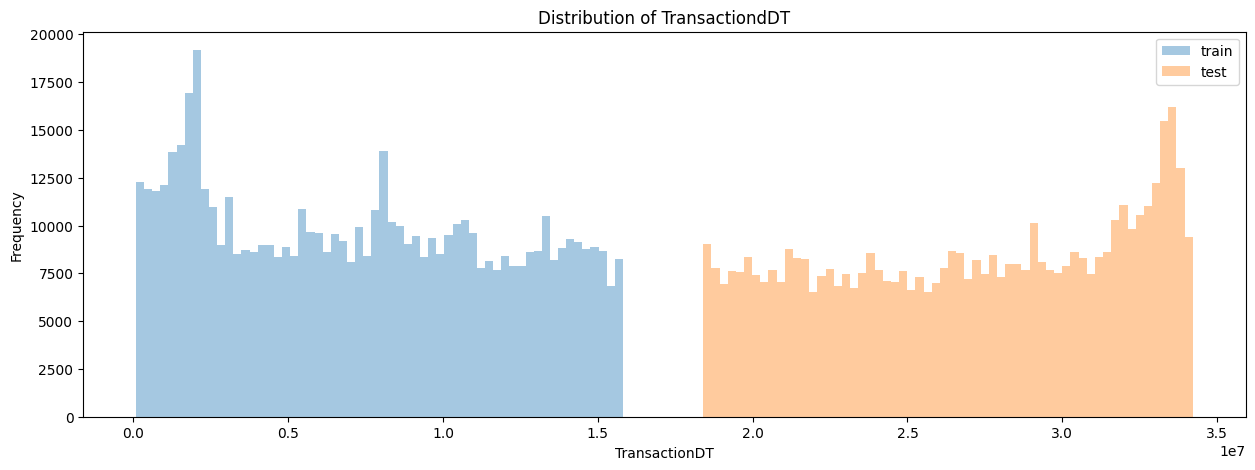

In [76]:
plt.figure(figsize = (15,5))
sns.distplot(train['TransactionDT'],kde = False,bins=60)
sns.distplot(test['TransactionDT'],kde = False,bins=60)
plt.legend(['train', 'test'])
plt.ylabel('Frequency')

plt.title('Distribution of TransactiondDT');
plt.show()

***> TransactionAmt Analysis***

In [77]:
print(train['TransactionAmt'].dtype)

print(train["TransactionAmt"].nunique())

print(train["TransactionAmt"].isnull().sum())
print(test["TransactionAmt"].isnull().sum())

float32
20902
0
0


In [78]:
print(train['TransactionAmt'].describe())
print(" ")
print(test['TransactionAmt'].describe())

count    590540.000000
mean        135.027161
std         239.162689
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64
 
count    506691.000000
mean        134.725571
std         245.790817
min           0.018000
25%          40.000000
50%          67.949997
75%         125.000000
max       10270.000000
Name: TransactionAmt, dtype: float64


In [79]:
train[train.TransactionAmt > 30000]

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
274336,3261336,0,6652360,31937.390625,W,16075,514.0,150.0,mastercard,102.0,credit,205.0,87.0,27.0,NaN,yahoo.com,NaN,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,T,T,NaN,NaN,NaN,F,F,T,1.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1422.390015,1422.390015,1422.390015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,1422.390015,1422.390015,1422.390015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
274339,3261339,0,665239

***> ProductCD Analysis***

In [80]:
print(train["ProductCD"].dtype)

print(train["ProductCD"].nunique())

print(train["ProductCD"].isnull().sum())
print(test["ProductCD"].isnull().sum())

object
5
0
0


In [81]:
train["ProductCD"].describe()

count     590540
unique         5
top            W
freq      439670
Name: ProductCD, dtype: object

In [82]:
train["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

/tmp/ipykernel_57/683254693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "ProductCD", y = "percentage", data = train_ProductCD, palette = 'pastel')
/tmp/ipykernel_57/683254693.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "ProductCD", y = "percentage", data = test_ProductCD, palette = 'pastel')


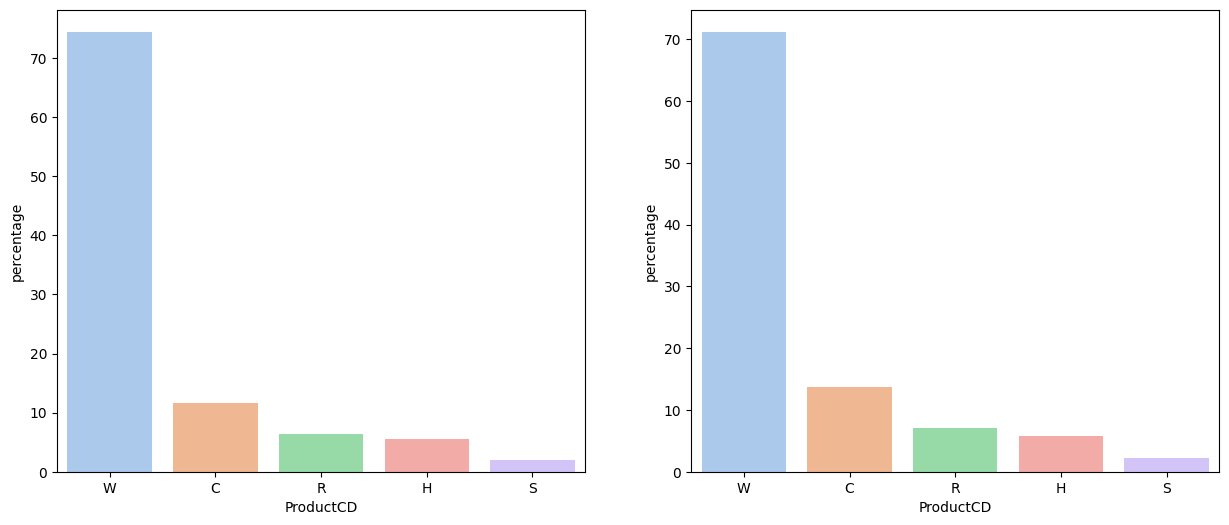

In [83]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
train_ProductCD = train['ProductCD'].value_counts(normalize=True).mul(100).rename('percentage')\
.reset_index()
sns.barplot(x = "ProductCD", y = "percentage", data = train_ProductCD, palette = 'pastel')

plt.subplot(1,2,2)
test_ProductCD = test['ProductCD'].value_counts(normalize=True).mul(100).rename('percentage')\
.reset_index()
sns.barplot(x = "ProductCD", y = "percentage", data = test_ProductCD, palette = 'pastel')

plt.show();

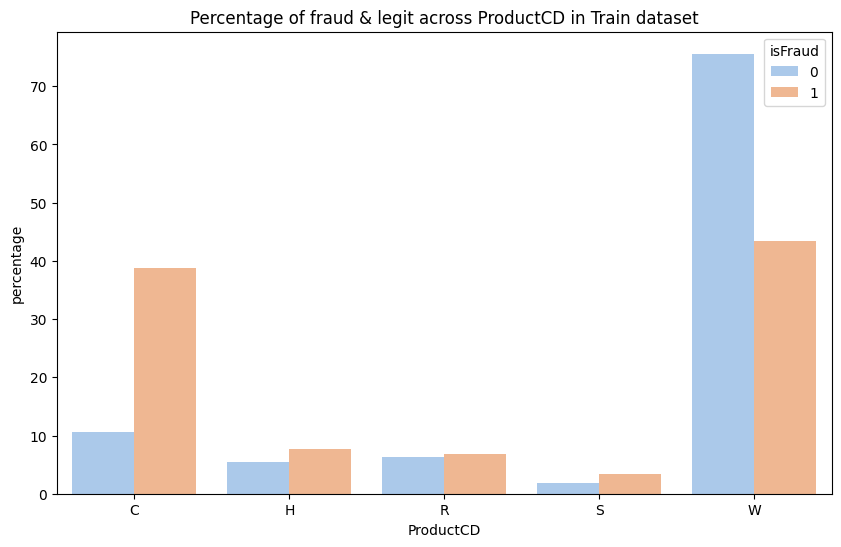

In [84]:
plt.figure(figsize = (10,6))

train_ProductCD = (train.groupby(['isFraud'])['ProductCD'].value_counts(normalize = True).rename('percentage').mul(100).reset_index().sort_values('ProductCD'))

sns.barplot(x = "ProductCD", y = "percentage", hue = "isFraud", data = train_ProductCD, palette = 'pastel')

plt.title('Percentage of fraud & legit across ProductCD in Train dataset')

plt.show();

***> DeviceType & DeviceInfo Analysis***

In [85]:
print(train["DeviceType"].dtype)

print(train['DeviceType'].isnull().sum())

print(train['DeviceType'].unique())

object
449730
[nan 'mobile' 'desktop']


In [86]:
train['DeviceType'].describe()

count      140810
unique          2
top       desktop
freq        85165
Name: DeviceType, dtype: object

In [87]:
train['DeviceType'].value_counts()

DeviceType
desktop    85165
mobile     55645
Name: count, dtype: int64

/tmp/ipykernel_57/3547096603.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x = "DeviceType", y = "percentage", data=test_DeviceType, palette = 'pastel')


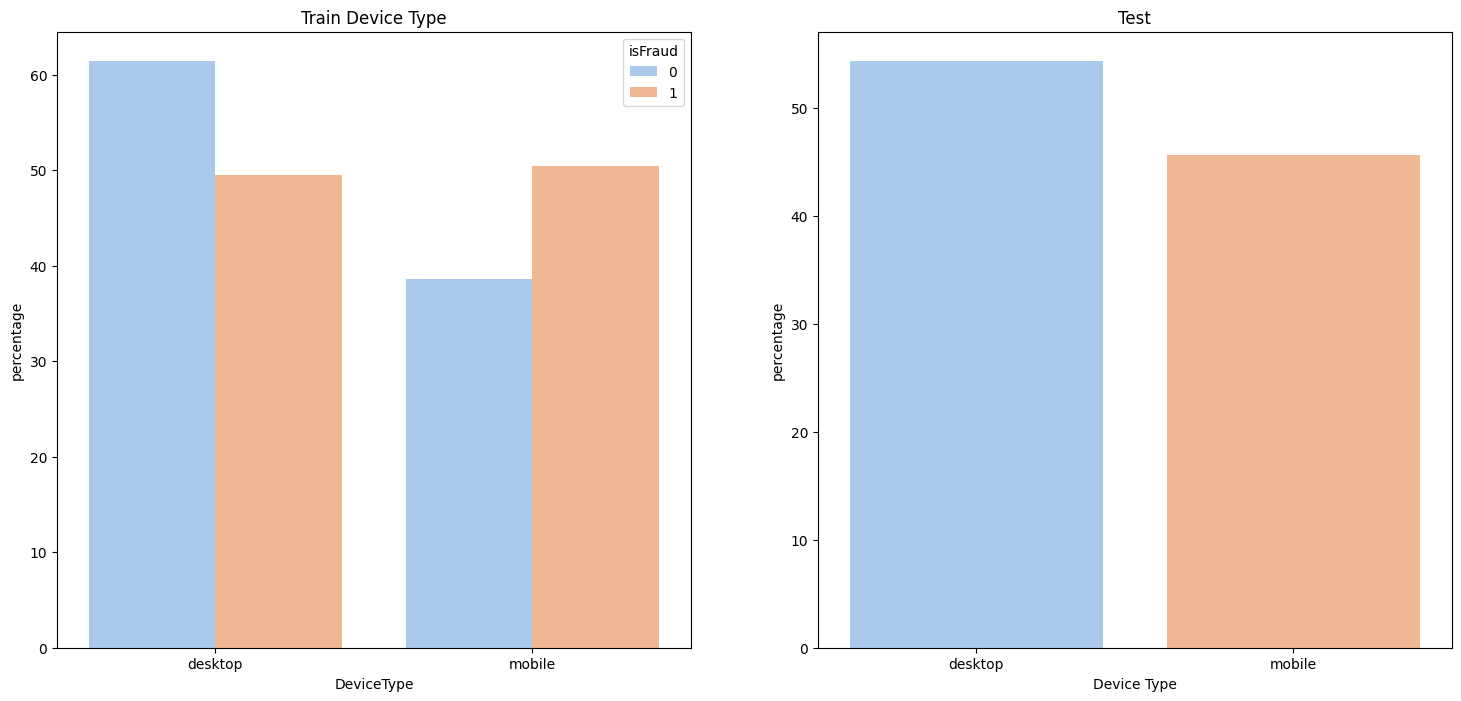

In [88]:
plt.figure(figsize = (18,8))

plt.subplot(1,2,1)

train_DeviceType = (train[~train['DeviceType'].isnull()].groupby(['isFraud'])['DeviceType'].value_counts(normalize=True).rename('percentage').mul(100).reset_index().sort_values('DeviceType'))
sns.barplot(x = "DeviceType", y = "percentage", hue = "isFraud", data = train_DeviceType, palette = 'pastel')
plt.title('Train Device Type')

plt.subplot(1,2,2)

test_DeviceType = test[~test['DeviceType'].isnull()]['DeviceType'].value_counts(normalize = True).mul(100).rename('percentage').reset_index()

sns.barplot( x = "DeviceType", y = "percentage", data=test_DeviceType, palette = 'pastel')
plt.xlabel('Device Type')
plt.title('Test')

plt.show()

In [89]:
print(train["DeviceInfo"].dtype)

print(train['DeviceInfo'].isnull().sum())

print(train['DeviceInfo'].unique())

object
471874
[nan 'SAMSUNG SM-G892A Build/NRD90M' 'iOS Device' ...
 'LDN-LX3 Build/HUAWEILDN-LX3' 'Z955A' 'LG-E975']


In [90]:
train["DeviceInfo"].describe()

count      118666
unique       1786
top       Windows
freq        47722
Name: DeviceInfo, dtype: object

In [91]:
train['DeviceInfo'].value_counts()[:5]

DeviceInfo
Windows        47722
iOS Device     19782
MacOS          12573
Trident/7.0     7440
rv:11.0         1901
Name: count, dtype: int64

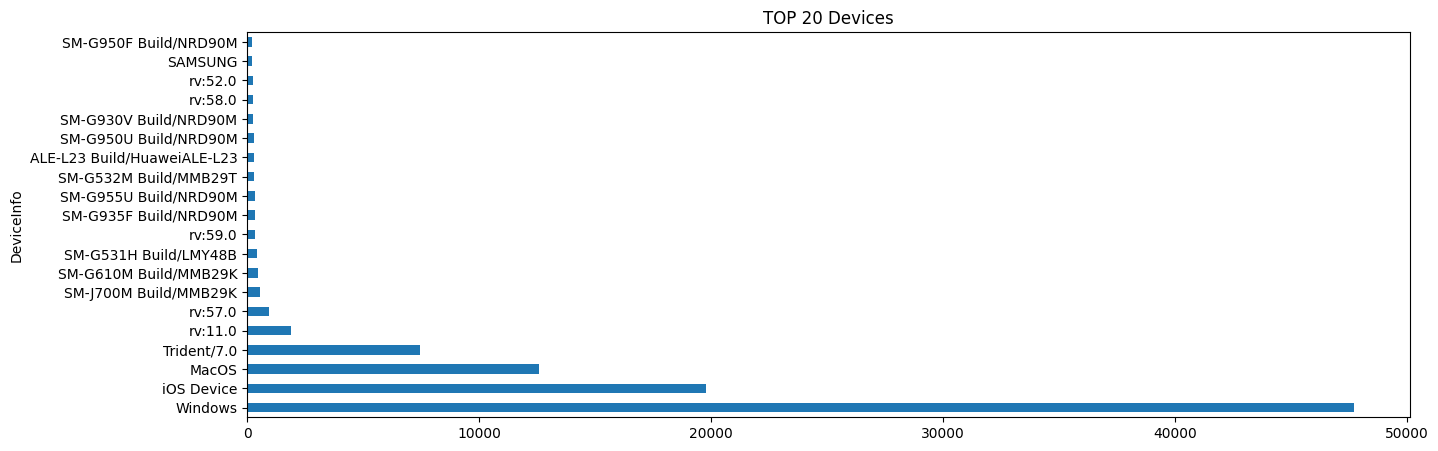

In [92]:
train.groupby('DeviceInfo') \
    .count()['TransactionID'] \
    .sort_values(ascending = False) \
    .head(20) \
    .plot(kind = 'barh', figsize = (15 , 5), title = 'TOP 20 Devices')
    
plt.show()

# Feature Engineering

In [93]:
train['day'] = ((train['TransactionDT'] //(3600*24)-1)%7)+1

test['day'] = ((test['TransactionDT'] //(3600*24)-1)%7)+1

/tmp/ipykernel_57/2737070471.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['day'] = ((train['TransactionDT'] //(3600*24)-1)%7)+1
/tmp/ipykernel_57/2737070471.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['day'] = ((test['TransactionDT'] //(3600*24)-1)%7)+1


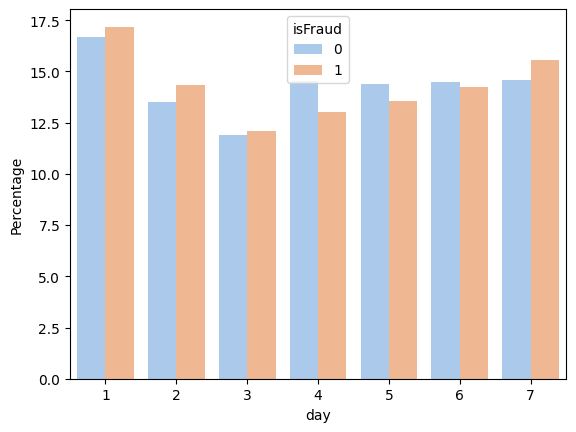

In [94]:
train_days = (train.groupby(['isFraud'])['day']
                     .value_counts(normalize=True)
                     .rename('Percentage')
                     .mul(100)
                     .reset_index()
                     .sort_values('day'))
sns.barplot(x="day", y = "Percentage", hue="isFraud", data = train_days, palette = 'pastel')
plt.show();

In [95]:
train['hour'] = ((train['TransactionDT']//3600)%24)+1

test['hour'] = ((test['TransactionDT']//3600)%24)+1

/tmp/ipykernel_57/1202968795.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['hour'] = ((train['TransactionDT']//3600)%24)+1
/tmp/ipykernel_57/1202968795.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['hour'] = ((test['TransactionDT']//3600)%24)+1


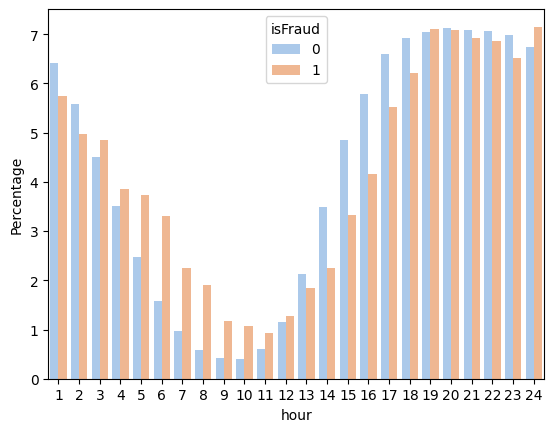

In [96]:
train_hour = (train.groupby(['isFraud'])['hour']
                     .value_counts(normalize = True)
                     .rename('Percentage')
                     .mul(100)
                     .reset_index()
                     .sort_values('hour'))
sns.barplot(x = "hour", y = "Percentage", hue = "isFraud", data = train_hour, palette = 'pastel')
plt.show();

In [97]:
def hourFeature(hour):
    if hour > 4 and hour < 12:
        return "highalert"
    if hour ==12 or hour==19:
        return "lowalert"
    if hour==3 or hour==4 or hour==24:
        return "mediumalert"
    else:
        return "noalert"


train['hour_alertFeature'] = train['hour'].apply(hourFeature)

test['hour_alertFeature'] = test['hour'].apply(hourFeature)

/tmp/ipykernel_57/1786035222.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['hour_alertFeature'] = train['hour'].apply(hourFeature)
/tmp/ipykernel_57/1786035222.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['hour_alertFeature'] = test['hour'].apply(hourFeature)


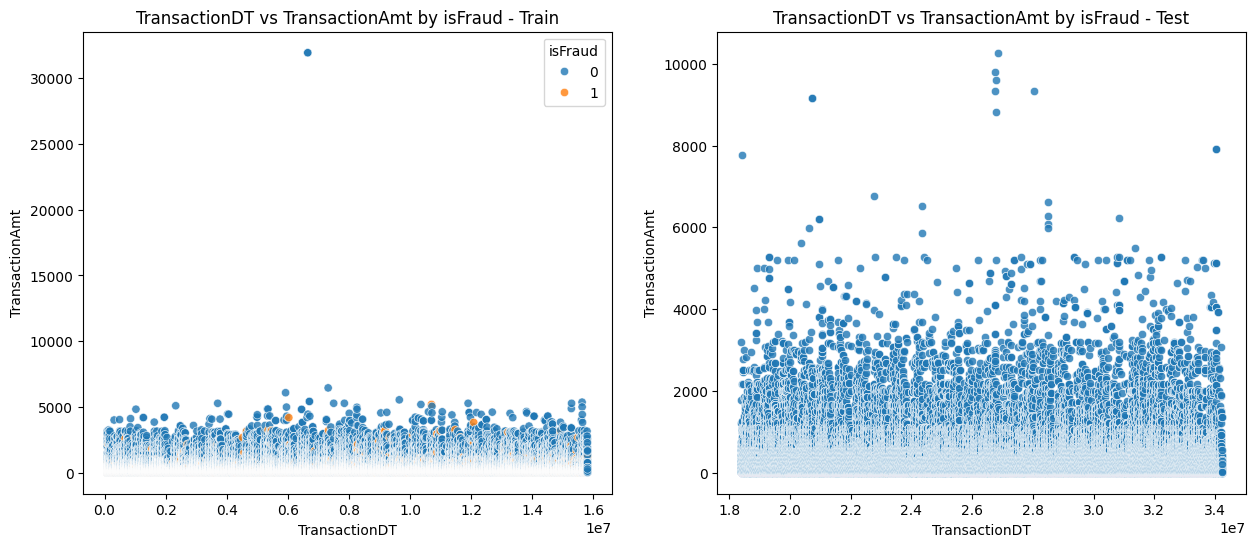

In [98]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
g1 = sns.scatterplot(x = "TransactionDT", y = "TransactionAmt", hue = "isFraud", data = train, alpha = 0.8, hue_order = [0,1])

plt.title('TransactionDT vs TransactionAmt by isFraud - Train')
plt.subplot(1,2,2)
sns.scatterplot(x = "TransactionDT",y="TransactionAmt", data=test, alpha=0.8, hue_order = [0,1])

plt.title('TransactionDT vs TransactionAmt by isFraud - Test')
plt.show()

In [99]:
# Remove 2 TransactionAmt Outliers.
train = train[train['TransactionAmt'] < 30000]

Text(0.5, 1.0, 'TransactionDT vs TransactionAmt by isFraud - Train')

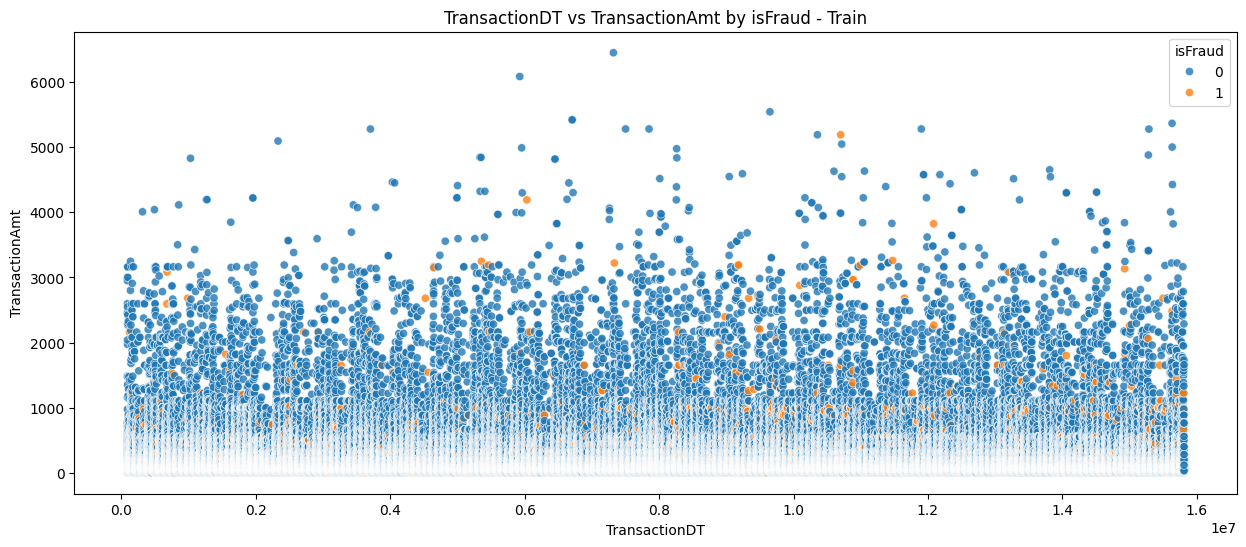

In [100]:
plt.figure(figsize = (15,6))
plt.plot()
g1 = sns.scatterplot(x = "TransactionDT", y = "TransactionAmt", hue = "isFraud", data = train, alpha = 0.8, hue_order = [0,1])

plt.title('TransactionDT vs TransactionAmt by isFraud - Train')

In [101]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,day,hour,hour_alertFeature
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,noalert
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmai

In [102]:
train.tail()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,day,hour,hour_alertFeature
590535,3577535,0,15811047,49.000000,W,6550,NaN,150.0,visa,226.0,debit,272.0,87.0,48.0,NaN,NaN,NaN,2.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,3.0,2.0,29.0,29.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN,56.0,56.0,NaN,NaN,NaN,56.0,T,T,T,M0,T,F,F,F,T,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,2.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,47.950001,0.000000,0.0,47.950001,0.0,0.0,47.950001,47.950001,47.950001,0.0,0.0,0.0,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,24,mediumale

In [103]:
c_cols = [f'C{i}' for i in range(1, 15) if f'C{i}' in train.columns]

c_nan_stats = (train[c_cols].isna().mean() * 100).reset_index()
c_nan_stats.columns = ['Feature', 'NaN_Percentage']

c_nan_stats = c_nan_stats.sort_values(by='NaN_Percentage', ascending=False)

print("C Features Missing Values Analysis:")
display(c_nan_stats)

C Features Missing Values Analysis:


,Feature,NaN_Percentage
0,C1,0.0
1,C2,0.0
2,C3,0.0
3,C4,0.0
4,C5,0.0
5,C6,0.0
6,C7,0.0
7,C8,0.0
8,C9,0.0
9,C10,0.0


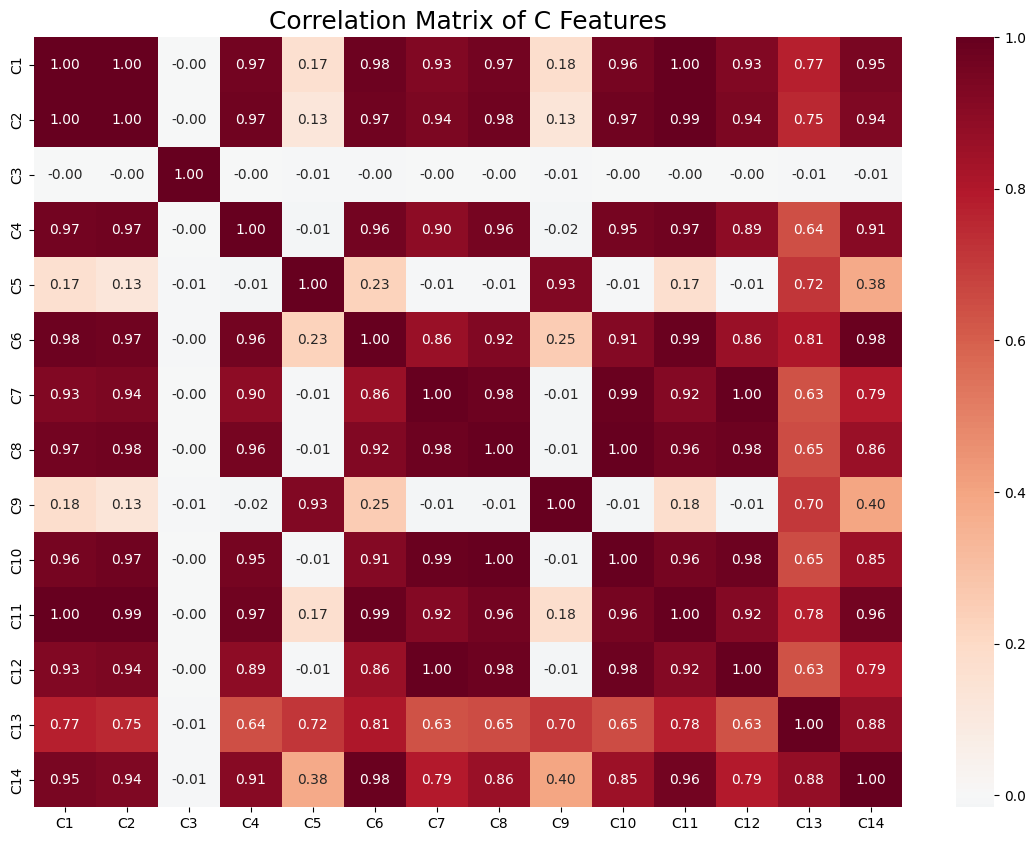

In [104]:
cor_c = train[c_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(cor_c, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Correlation Matrix of C Features', fontsize=18)
plt.show()

In [105]:
upper_c = cor_c.abs().where(np.triu(np.ones(cor_c.shape), k=1).astype(bool))

# Corr > 0.95 Threshold
to_drop_c = [column for column in upper_c.columns if any(upper_c[column] > 0.95)]


train.drop(columns=to_drop_c, inplace=True)
test.drop(columns=to_drop_c, inplace=True)

print(f"Deleted C Features: {to_drop_c}")

Deleted C Features: ['C2', 'C4', 'C6', 'C8', 'C10', 'C11', 'C12', 'C14']


In [106]:
d_cols = [f'D{i}' for i in range(1, 16) if f'D{i}' in train.columns]

d_nan_stats = (train[d_cols].isna().mean() * 100).reset_index()
d_nan_stats.columns = ['Feature', 'NaN_Percentage']

# Correlation with target
d_correlations = train[d_cols + ['isFraud']].corr()['isFraud'].reset_index()
d_correlations.columns = ['Feature', 'Correlation']

d_summary = pd.merge(d_nan_stats, d_correlations, on='Feature').sort_values(by='NaN_Percentage', ascending=False)

print("D Features: Missing Values & Correlation Analysis")
display(d_summary)

D Features: Missing Values & Correlation Analysis


,Feature,NaN_Percentage,Correlation
6,D7,93.409908,-0.127199
12,D13,89.509227,-0.059430
13,D14,89.469433,-0.008663
11,D12,89.041010,-0.028864
5,D6,87.606725,-0.057236
7,D8,87.312247,-0.142636
8,D9,87.312247,-0.044253
4,D5,52.467580,-0.064638
1,D2,47.549015,-0.083583
10,D11,47.293654,-0.045095


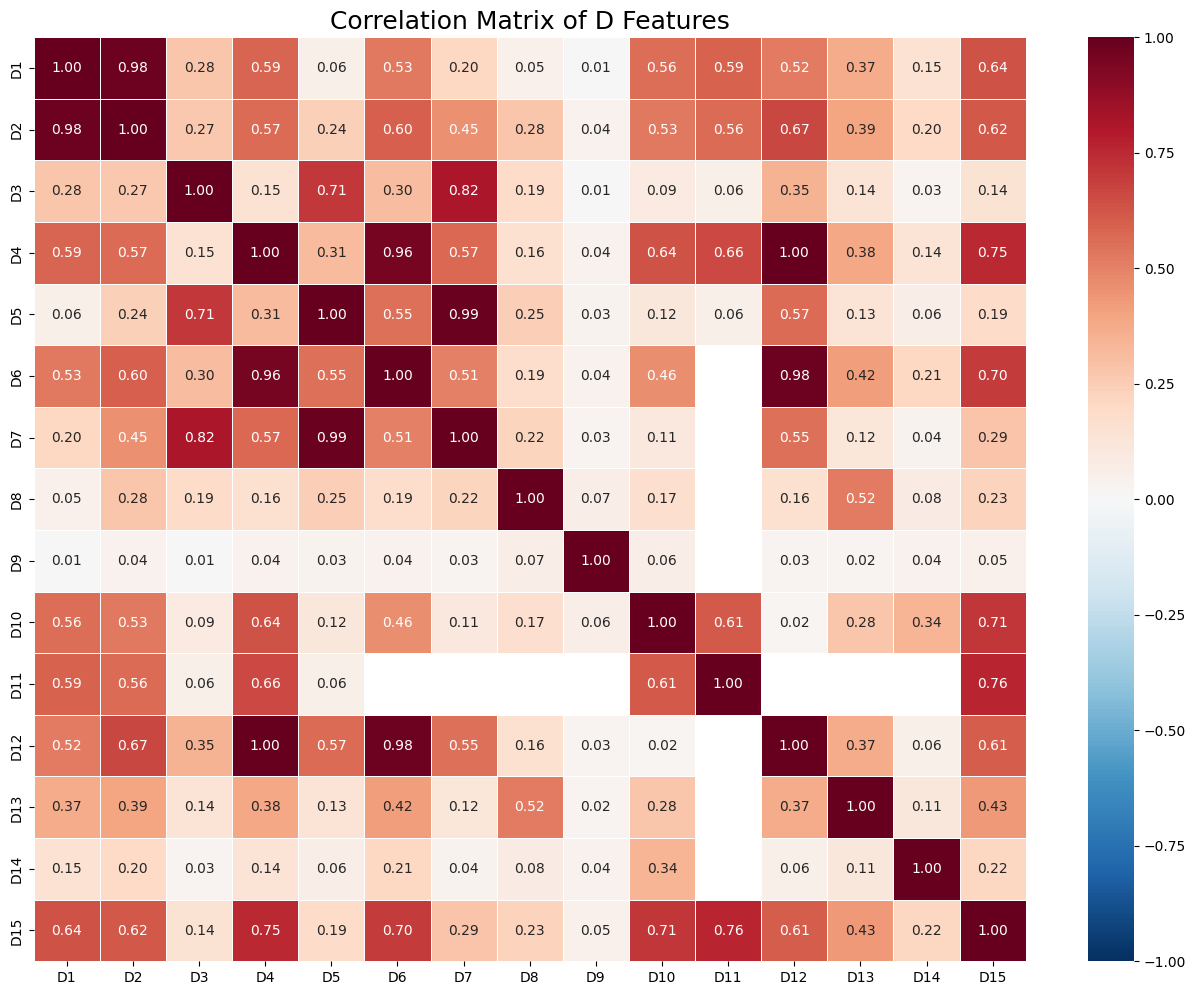

In [107]:
import seaborn as sns

cor = train[d_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(cor, 
            annot=True,         
            fmt=".2f",           
            cmap='RdBu_r',       
            vmin=-1, vmax=1,   
            center=0,
            linewidths=0.5,      
            linecolor='white')  

plt.title('Correlation Matrix of D Features', fontsize=18)
plt.show()

In [108]:
upper = cor.abs().where(np.triu(np.ones(cor.shape), k=1).astype(bool))

# Corr > 0.95 threshold
to_drop_d = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"Deleted D Features: {to_drop_d}")

train.drop(columns=to_drop_d, inplace=True)
test.drop(columns=to_drop_d, inplace=True)

Deleted D Features: ['D2', 'D6', 'D7', 'D12']


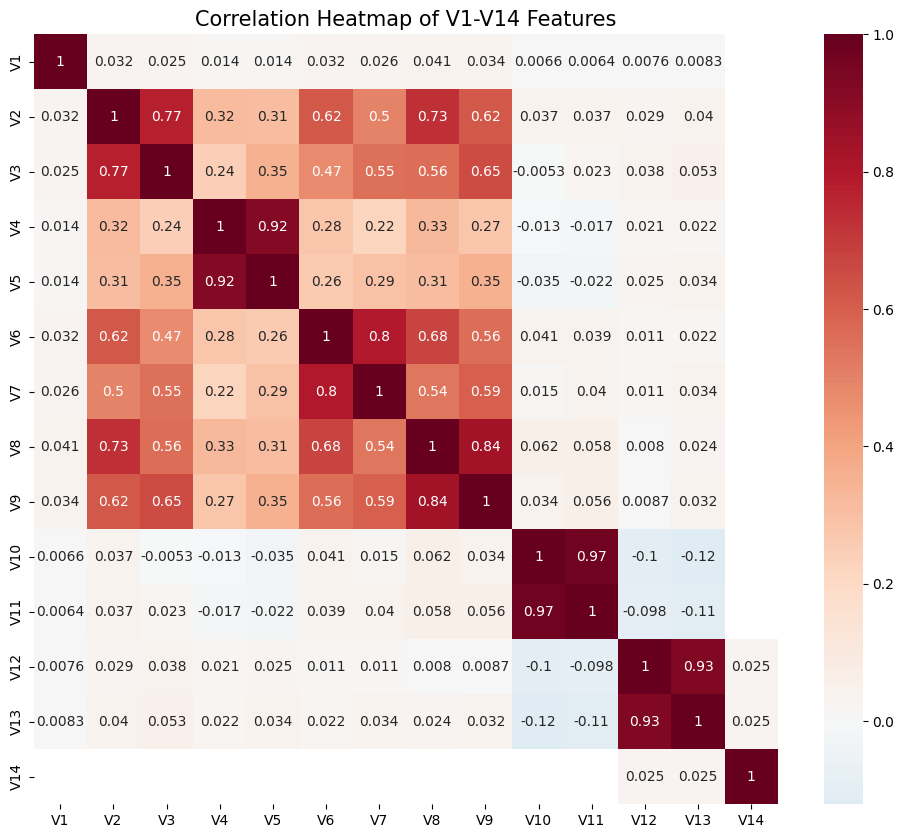

In [109]:
v_cols = [f'V{i}' for i in range(1, 15)]
plt.figure(figsize=(12, 10))
sns.heatmap(train[v_cols].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of V1-V14 Features', fontsize=15)
plt.show()

In [110]:
# Removing useless V columns with LGBM

from lightgbm import LGBMClassifier
import pandas as pd

v_features = [c for c in train.columns if c.startswith('V')]

split_idx = int(train.shape[0] * 0.70)

X_v_train = train[v_features].iloc[:split_idx]
y_v_train = train['isFraud'].iloc[:split_idx]
X_v_val = train[v_features].iloc[split_idx:]
y_v_val = train['isFraud'].iloc[split_idx:]

clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1 
)

clf.fit(X_v_train, y_v_train)

v_importance = pd.DataFrame({
    'feature': v_features,
    'importance': clf.feature_importances_
})

v_to_remove = v_importance[v_importance['importance'] < 3]['feature'].tolist()

print(f"Total number of V columns: {len(v_features)}")
print(f"V columns to delete: {len(v_to_remove)}")
print(f"Needed V columns: {len(v_features) - len(v_to_remove)}")

train.drop(columns=v_to_remove, inplace=True)
test.drop(columns=v_to_remove, inplace=True)


[LightGBM] [Info] Number of positive: 14538, number of negative: 398838
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.530450 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 23391
[LightGBM] [Info] Number of data points in the train set: 413376, number of used features: 337
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035169 -> initscore=-3.311789
[LightGBM] [Info] Start training from score -3.311789
Total number of V columns: 339
V columns to delete: 119
Needed V columns: 220


In [111]:
# To catch sudden big amount transaction from a card

train['card1_amt_mean'] = train.groupby('card1')['TransactionAmt'].transform('mean')
test['card1_amt_mean'] = test.groupby('card1')['TransactionAmt'].transform('mean')

# Ratio of transaction
train['TransactionAmt_to_mean_card1'] = train['TransactionAmt'] / train['card1_amt_mean']
test['TransactionAmt_to_mean_card1'] = test['TransactionAmt'] / test['card1_amt_mean']

train.drop('card1_amt_mean', axis=1, inplace=True)
test.drop('card1_amt_mean', axis=1, inplace=True)

print("New Feature 'TransactionAmt_to_mean_card1'")

/tmp/ipykernel_57/1131776515.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['card1_amt_mean'] = train.groupby('card1')['TransactionAmt'].transform('mean')
/tmp/ipykernel_57/1131776515.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['card1_amt_mean'] = test.groupby('card1')['TransactionAmt'].transform('mean')
/tmp/ipykernel_57/1131776515.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

New Feature 'TransactionAmt_to_mean_card1'


In [112]:
id_cols = [c for c in train.columns if c.startswith('id_')]

id_na_stats = train[id_cols].isna().mean()

print(id_na_stats)

id_01    0.755760
id_02    0.761451
id_03    0.887689
id_04    0.887689
id_05    0.768237
id_06    0.768237
id_07    0.991271
id_08    0.991271
id_09    0.873122
id_10    0.873122
id_11    0.761272
id_12    0.755760
id_13    0.784400
id_14    0.864456
id_15    0.761260
id_16    0.780979
id_17    0.763997
id_18    0.923607
id_19    0.764083
id_20    0.764179
id_21    0.991264
id_22    0.991247
id_23    0.991247
id_24    0.991962
id_25    0.991310
id_26    0.991257
id_27    0.991247
id_28    0.761272
id_29    0.761272
id_30    0.868654
id_31    0.762451
id_32    0.868618
id_33    0.875895
id_34    0.868247
id_35    0.761260
id_36    0.761260
id_37    0.761260
id_38    0.761260
dtype: float64


In [113]:
train.isin([np.inf, -np.inf]).sum().any()

np.False_

In [114]:
# Frequency Encoding 

freq_cols = ['card1', 'card2', 'card3', 'card5', 
             'addr1', 'addr2', 
             'P_emaildomain', 'R_emaildomain']

for col in freq_cols:
    if col in train.columns:
        # Count frequencies from TRAIN only
        mapping = train[col].astype('object').value_counts(dropna=False)
        
        train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
        
        test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
        
        print(f"Frequency encoding finished: {col}")

train = train.copy()
test = test.copy()

/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
/tmp/ipykernel_57/282815845.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

Frequency encoding finished: card1
Frequency encoding finished: card2


/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
/tmp/ipykernel_57/282815845.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

Frequency encoding finished: card3
Frequency encoding finished: card5


/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
/tmp/ipykernel_57/282815845.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

Frequency encoding finished: addr1
Frequency encoding finished: addr2


/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train[col + '_freq'] = train[col].astype('object').map(mapping).astype('int32')
/tmp/ipykernel_57/282815845.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test[col + '_freq'] = test[col].astype('object').map(mapping).fillna(0).astype('int32')
/tmp/ipykernel_57/282815845.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all c

Frequency encoding finished: P_emaildomain
Frequency encoding finished: R_emaildomain


In [129]:
# # How many transactions has this card made? (activity level)
# train['card1_count'] = train.groupby('card1')['TransactionAmt'].transform('count')
# test['card1_count'] = test.groupby('card1')['TransactionAmt'].transform('count')

# # Std of amounts for this card (consistency checker)
# train['card1_amt_std'] = train.groupby('card1')['TransactionAmt'].transform('std').fillna(0)
# test['card1_amt_std'] = test.groupby('card1')['TransactionAmt'].transform('std').fillna(0)

# train['email_mismatch'] = (train['P_emaildomain'] != train['R_emaildomain']).astype(int)
# test['email_mismatch'] = (test['P_emaildomain'] != test['R_emaildomain']).astype(int)

# train['amt_decimal'] = train['TransactionAmt'] % 1
# test['amt_decimal'] = test['TransactionAmt'] % 1

# Models

In [115]:
y = train['isFraud']
X = train.drop(columns=['isFraud', 'TransactionID'])

results_df = pd.DataFrame(columns=['Run Name', 'Estimators', 'Max Depth', 'Learning Rate', 'AUC Score', 'Notes'])

In [116]:
X_test = test.drop(['TransactionID'], axis=1)
X_test.columns = X_test.columns.str.replace('-', '_')

object_cols = X.select_dtypes(include=['object']).columns
for col in object_cols:
    le = LabelEncoder()
    full_values = pd.concat([X[col], X_test[col]]).astype(str)
    le.fit(full_values)
    X[col] = le.transform(X[col].astype(str)).astype('int32')
    X_test[col] = le.transform(X_test[col].astype(str)).astype('int32')

In [117]:
run_baseline = False  

if run_baseline:
    
    # Preprocessing 
    X_numeric = X.select_dtypes(include=['number'])
    X_numeric = X_numeric.fillna(-999)

    X_train, X_val, y_train, y_val = train_test_split(
        X_numeric, y, test_size=0.2, random_state=42, stratify=y
    )

    del X_numeric
    gc.collect()

    params = {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": 'hist',
        "device": 'cuda',
        "random_state": 42
    }

    
    with mlflow.start_run(run_name="XGBoost_Baseline"):
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        auc_score = roc_auc_score(y_val, y_pred_proba)
        
        mlflow.log_params(params)
        mlflow.log_metric("auc", auc_score)
        mlflow.sklearn.log_model(model, "xgboost_baseline_model")

        new_result = pd.DataFrame([{
            'Run Name': "XGBoost_Baseline",
            'Estimators': params["n_estimators"],
            'Max Depth': params["max_depth"],
            'Learning Rate': params["learning_rate"],
            'AUC Score': round(auc_score, 4),
            'Notes': 'Numeric only, fillna(-999)'
        }])
        
        if 'results_df' not in locals():
            results_df = new_result
        else:
            results_df = pd.concat([results_df, new_result], ignore_index=True)

    print(f"AUC: {auc_score:.4f}")
    
    del X_train, X_val, y_train, y_val, model
    gc.collect()
    
else:
    print("XGBoost_Baseline is skipped !")


XGBoost_Baseline is skipped !


,Run Name,Estimators,Max Depth,Learning Rate,AUC Score,Notes


In [118]:
run_categorical = False 

if run_categorical:
    
    X_cat = X.copy()
    
    # Label Encoding 
    from sklearn.preprocessing import LabelEncoder
    obj_cols = X_cat.select_dtypes(include=['object']).columns
    
    for col in obj_cols:
        le = LabelEncoder()
        X_cat[col] = le.fit_transform(X_cat[col].astype(str))
    
    X_cat = X_cat.fillna(-999)
    X_train, X_val, y_train, y_val = train_test_split(
        X_cat, y, test_size=0.2, random_state=42, stratify=y
    )

    params = {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": 'hist',
        "device": 'cuda',
        "random_state": 42
    }

    with mlflow.start_run(run_name="XGBoost_Categorical"):
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        auc_score = roc_auc_score(y_val, y_pred_proba)
        
        mlflow.log_params(params)
        mlflow.log_metric("auc", auc_score)

        new_result = pd.DataFrame([{
            'Run Name': "XGBoost_Categorical",
            'Estimators': params["n_estimators"],
            'Max Depth': params["max_depth"],
            'Learning Rate': params["learning_rate"],
            'AUC Score': round(auc_score, 4),
            'Notes': 'All features, LabelEncoding on Objects'
        }])
        results_df = pd.concat([results_df, new_result], ignore_index=True)

    print(f"✅ Finished! AUC: {auc_score:.4f}")
    
    del X_train, X_val, y_train, y_val, model, X_cat
    import gc
    gc.collect()

else:
    print("XGBoost_Categorical is skipped!")


XGBoost_Categorical is skipped!


,Run Name,Estimators,Max Depth,Learning Rate,AUC Score,Notes


In [119]:
run_cleaning = False

if run_cleaning:
    X_clean = X.copy()
    
    na_rate = X_clean.isna().mean()
    cols_to_drop_nulls = na_rate[na_rate > 0.90].index.tolist() # 0.90 null threshold
    X_clean = X_clean.drop(columns=cols_to_drop_nulls)

    # Label Encoding 
    from sklearn.preprocessing import LabelEncoder
    for col in X_clean.select_dtypes(include=['object']).columns:
        X_clean[col] = LabelEncoder().fit_transform(X_clean[col].astype(str))

    # Correlation Filter 
    corr_matrix = X_clean.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_clean = X_clean.drop(columns=to_drop_corr)

    print(f"Dropped: {len(cols_to_drop_nulls)} (High Nulls), {len(to_drop_corr)} (High Corr)")
    print(f"Remaining features: {X_clean.shape[1]}")

    X_clean = X_clean.fillna(-999)
    X_train, X_val, y_train, y_val = train_test_split(X_clean, y, test_size=0.2, random_state=42, stratify=y)

    with mlflow.start_run(run_name="XGBoost_Cleaning"):
        params = {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "tree_method": 'hist',
            "device": 'cuda',
            "random_state": 42
        }
        
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        
        auc_score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

        mlflow.log_params(params)
        mlflow.log_param("features_count", X_clean.shape[1])
        
        mlflow.log_metric("auc", auc_score)

        mlflow.sklearn.log_model(model, "model")
        
        new_result = pd.DataFrame([{
            'Run Name': "XGBoost_Cleaning",
            'Estimators': params["n_estimators"],
            'Max Depth': params["max_depth"],
            'Learning Rate': params["learning_rate"],
            'AUC Score': round(auc_score, 4),
            'Notes': 'Dropped Nulls>90% & Corr>0.95'
        }])
        results_df = pd.concat([results_df, new_result], ignore_index=True)

    print(f"AUC: {auc_score:.4f}")
    
    del X_train, X_val, y_train, y_val, model, X_clean
    import gc
    gc.collect()


,Run Name,Estimators,Max Depth,Learning Rate,AUC Score,Notes


In [120]:
run_cleaning_final = False

if run_cleaning_final:

    X_final = train.drop(columns=['isFraud', 'TransactionID']).copy()
    y_final = train['isFraud']
    
    nan_rate = X_final.isna().mean()
    cols_to_drop = nan_rate[nan_rate > 0.80].index.tolist()
    
    for col in X_final.columns:
        if X_final[col].nunique() <= 1:
            cols_to_drop.append(col)
        else:
            top_val_share = X_final[col].value_counts(normalize=True).values[0]
            if top_val_share > 0.95:
                cols_to_drop.append(col)
    
    cols_to_drop = list(set(cols_to_drop))
    X_final = X_final.drop(columns=cols_to_drop)
    print(f"Dropped {len(cols_to_drop)} useless columns.")

    for col in ['card1', 'addr1']:
        if col in X_final.columns:
            if X_final[col].dtype == 'float16':
                X_final[col] = X_final[col].astype('float32')
            vc = X_final[col].value_counts().to_dict()
            X_final[f'{col}_count'] = X_final[col].map(vc)

    from sklearn.preprocessing import LabelEncoder
    for col in X_final.select_dtypes(include=['object']).columns:
        X_final[col] = LabelEncoder().fit_transform(X_final[col].astype(str))
    
    X_final = X_final.fillna(-999)
    X_train, X_val, y_train, y_val = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

    with mlflow.start_run(run_name="XGBoost_Cleaning_Final"):
        params = {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "tree_method": 'hist',
            "device": 'cuda',
            "random_state": 42
        }
        
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        
        auc_score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        
        mlflow.log_params(params)
        mlflow.log_metric("auc", auc_score)
        mlflow.log_param("dropped_cols", len(cols_to_drop))

        mlflow.sklearn.log_model(model, "model")

        new_result = pd.DataFrame([{
            'Run Name': "XGBoost_Cleaning_Final",
            'Estimators': 500, 'Max Depth': 6, 'Learning Rate': 0.05,
            'AUC Score': round(auc_score, 4),
            'Notes': 'Maximum of just cleaning'
        }])
        results_df = pd.concat([results_df, new_result], ignore_index=True)

    print(f"AUC: {auc_score:.4f}")
    
    del X_train, X_val, y_train, y_val, model, X_final
    import gc
    gc.collect()


,Run Name,Estimators,Max Depth,Learning Rate,AUC Score,Notes


In [121]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import gc



run_80_20 = False

if run_80_20:

    split_index = int(len(X) * 0.8)

    X_train, X_val = X.iloc[:split_index], X.iloc[split_index:]
    y_train, y_val = y.iloc[:split_index], y.iloc[split_index:]

    params = {
        'n_estimators': 2000,
        'max_depth': 12,
        'learning_rate': 0.02,
        'subsample': 0.8,
        'colsample_bytree': 0.4,
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': 42,
        'missing': -999,
        'early_stopping_rounds': 100  
    }

    with mlflow.start_run(run_name="XGBoost_80_20_Time_Split"):
        mlflow.log_params(params)
        mlflow.log_param("features_count", X.shape[1])
        mlflow.log_param("split_strategy", "Chronological 80/20")

        model = xgb.XGBClassifier(**params)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=100
        )
        
        train_preds = model.predict_proba(X_train)[:, 1]
        val_preds = model.predict_proba(X_val)[:, 1]
        
        train_auc = roc_auc_score(y_train, train_preds)
        val_auc = roc_auc_score(y_val, val_preds)
        
        mlflow.log_metric("train_auc", train_auc)
        mlflow.log_metric("val_auc", val_auc)
        
        print(f"📊 Train AUC: {train_auc:.5f}")
        print(f"📊 Validation AUC: {val_auc:.5f}")
        
        test_preds = model.predict_proba(X_test)[:, 1]
        
        mlflow.xgboost.log_model(model, "model")

    submission = pd.DataFrame({
        'TransactionID': test['TransactionID'],
        'isFraud': test_preds
    })

    submission.to_csv('submission_80_20_split.csv', index=False)

    del X_train, X_val, y_train, y_val, model
    gc.collect()
else:
    print("Skipped")

Skipped


In [122]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import xgboost as xgb
import mlflow
import gc

RUN_TUNING = False  

if RUN_TUNING:
    
    tscv = TimeSeriesSplit(n_splits=3)

    base_model = xgb.XGBClassifier(
        n_estimators=300, 
        tree_method='hist', 
        device='cuda',
        missing=-999,
        random_state=42
    )

    param_dist = {
        'max_depth': [5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.7, 0.8, 0.9],
        'colsample_bytree': [0.4, 0.7, 0.9],
        'min_child_weight': [1, 5, 10],
        'reg_lambda': [1, 5, 10]
    }

    random_search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_dist,
        n_iter=10,
        scoring='roc_auc',
        cv=tscv,
        verbose=2,
        random_state=42,
        n_jobs=1
    )

    with mlflow.start_run(run_name="XGBoost_Hyperparameter_Tuning"):
        random_search.fit(X, y)
        
        best_params = random_search.best_params_
        best_cv_score = random_search.best_score_
        
        print("\n✅ Tuning დასრულდა!")
        print(f"🏆 Best Parameters: {best_params}")
        print(f"📊 Best CV AUC Score: {best_cv_score:.5f}")
        
        mlflow.log_params(best_params)
        mlflow.log_metric("best_cv_auc", best_cv_score)
        
        best_model = random_search.best_estimator_
        mlflow.xgboost.log_model(best_model, "tuned_model")

    gc.collect()
else:
    print("⏭️ Hyperparameter Tuning skipped")

⏭️ Hyperparameter Tuning skipped


In [130]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import pandas as pd
import mlflow
import gc

train_idx = int(len(X) * 0.70)
val_idx = int(len(X) * 0.85)

X_train, y_train = X.iloc[:train_idx], y.iloc[:train_idx]
X_val, y_val = X.iloc[train_idx:val_idx], y.iloc[train_idx:val_idx]
X_local_test, y_local_test = X.iloc[val_idx:], y.iloc[val_idx:]

scale = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight = {scale:.1f}")

best_params = {
    'n_estimators': 3000,
    'max_depth': 6,
    'learning_rate': 0.02,
    'subsample': 0.7,
    'colsample_bytree': 0.4,
    'colsample_bylevel': 0.6,
    'min_child_weight': 15,
    'reg_lambda': 10,
    'reg_alpha': 5,
    'scale_pos_weight': 5,  # ← 27.6, the real ratio from your data
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'missing': -999,
    'early_stopping_rounds': 150
}

with mlflow.start_run(run_name="XGBoost_BestModel"):
    mlflow.log_params(best_params)
    
    model = xgb.XGBClassifier(**best_params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=100
    )
    
    train_probs = model.predict_proba(X_train)[:, 1]
    val_probs = model.predict_proba(X_val)[:, 1]
    test_probs = model.predict_proba(X_local_test)[:, 1]
    
    test_preds = model.predict(X_local_test)
    
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    test_auc = roc_auc_score(y_local_test, test_probs)
    
    test_precision = precision_score(y_local_test, test_preds)
    test_recall = recall_score(y_local_test, test_preds)
    test_f1 = f1_score(y_local_test, test_preds)
    
    mlflow.log_metric("train_auc", train_auc)
    mlflow.log_metric("val_auc", val_auc)
    mlflow.log_metric("local_test_auc", test_auc)
    mlflow.log_metric("local_test_precision", test_precision)
    mlflow.log_metric("local_test_recall", test_recall)
    mlflow.log_metric("local_test_f1", test_f1)
    
    print("\n" + "="*40)
    print("🎯 Final Results !!!")
    print("="*40)
    print(f"📊 Train AUC: {train_auc:.5f}")
    print(f"📊 Validation AUC: {val_auc:.5f}")
    print(f"📊 Local Test AUC: {test_auc:.5f}")
    print("-" * 40)
    print(f"🔍 Test Precision: {test_precision:.5f}")
    print(f"🎣 Test Recall: {test_recall:.5f}")
    print(f"⚖️ Test F1-Score: {test_f1:.5f}")
    print("="*40)
    
    mlflow.xgboost.log_model(model, "tuned_model")
    

del X_train, X_val, X_local_test, y_train, y_val, y_local_test
gc.collect()

scale_pos_weight = 27.6
[0]	validation_0-logloss:0.68877	validation_1-logloss:0.68824
[100]	validation_0-logloss:0.42639	validation_1-logloss:0.42912
[200]	validation_0-logloss:0.36506	validation_1-logloss:0.38023
[300]	validation_0-logloss:0.33524	validation_1-logloss:0.35850
[400]	validation_0-logloss:0.31553	validation_1-logloss:0.34213
[500]	validation_0-logloss:0.29994	validation_1-logloss:0.33034
[600]	validation_0-logloss:0.28770	validation_1-logloss:0.31864
[700]	validation_0-logloss:0.27747	validation_1-logloss:0.30278
[800]	validation_0-logloss:0.26765	validation_1-logloss:0.29101
[900]	validation_0-logloss:0.25890	validation_1-logloss:0.27637
[1000]	validation_0-logloss:0.25081	validation_1-logloss:0.26346
[1100]	validation_0-logloss:0.24369	validation_1-logloss:0.25303
[1200]	validation_0-logloss:0.23600	validation_1-logloss:0.24452
[1300]	validation_0-logloss:0.22975	validation_1-logloss:0.23301
[1400]	validation_0-logloss:0.22355	validation_1-logloss:0.22494
[1500]	valida

2026/05/03 19:34:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



🎯 Final Results !!!
📊 Train AUC: 0.99212
📊 Validation AUC: 0.92204
📊 Local Test AUC: 0.90647
----------------------------------------
🔍 Test Precision: 0.39987
🎣 Test Recall: 0.59066
⚖️ Test F1-Score: 0.47689
🏃 View run XGBoost_Hyperparameter_Selection_N3 at: https://dagshub.com/Sula1909/ML-Assignment2.mlflow/#/experiments/0/runs/88855c5df3094469b653388d24145699
🧪 View experiment at: https://dagshub.com/Sula1909/ML-Assignment2.mlflow/#/experiments/0


770